In [1]:
!git clone https://github.com/garythung/trashnet.git
!pip install --quiet split-folders
!pip install ttach

Cloning into 'trashnet'...
remote: Enumerating objects: 45, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 45 (delta 6), reused 0 (delta 0), pack-reused 33 (from 1)
Receiving objects: 100% (45/45), 40.64 MiB | 16.94 MiB/s, done.
Resolving deltas: 100% (12/12), done.


In [2]:
import zipfile
import os

zip_path = "/kaggle/working/trashnet/data/dataset-resized.zip"
extract_path = "/kaggle/working/trashnet/data"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    # Chỉ giải nén các file KHÔNG thuộc __MACOSX
    for member in zip_ref.namelist():
        if "__MACOSX" not in member and not member.endswith('/'):
            zip_ref.extract(member, extract_path)

print("✅ Giải nén xong (bỏ qua __MACOSX).")

✅ Giải nén xong (bỏ qua __MACOSX).


In [3]:
import splitfolders

input_folder = "/kaggle/working/trashnet/data/dataset-resized"
output_folder = "/kaggle/working/trashnet/data/trashnet-split"

splitfolders.ratio(
    input=input_folder,
    output=output_folder,
    seed=42,
    ratio=(.7, .15, .15),  # train, val, test
    group_prefix=None  # không cần nhóm theo tiền tố tên file
)
print("done")

Copying files: 2527 files [00:00, 7693.79 files/s]

done


In [4]:
# Data Preprocessing & Data Augmentation
from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),  
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05), shear=10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.05),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.3), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize(256),      
    transforms.CenterCrop(224),   
    transforms.ToTensor(),
    
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("done")

done


In [5]:
# Data Loading

from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder

data_dir = "/kaggle/working/trashnet/data/trashnet-split"

train_dataset = ImageFolder(f"{data_dir}/train", transform=train_transforms)
val_dataset = ImageFolder(f"{data_dir}/val", transform=val_test_transforms)
test_dataset = ImageFolder(f"{data_dir}/test", transform=val_test_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Train:", len(train_dataset), " | Val:", len(val_dataset), " | Test:", len(test_dataset))

Train: 1766  | Val: 377  | Test: 384


**Load model**

In [6]:
## Kích hoạt gpu
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [7]:
num_classes = len(train_dataset.classes)
print(f'Số lượng phân loại : {num_classes}\n{train_dataset.classes}')

Số lượng phân loại : 6
['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [8]:
import torch.nn as nn
import torchvision.models as models
import copy

resnet18 = models.resnet18(weights='IMAGENET1K_V1')

num_ftrs = resnet18.fc.in_features

resnet18.fc = nn.Sequential(
    nn.Linear(num_ftrs, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(inplace = True),
    nn.Dropout(p = 0.4),
    nn.Linear(256, num_classes)
)

resnet18_1 = copy.deepcopy(resnet18)
resnet18_2 = copy.deepcopy(resnet18)

for param in resnet18_1.parameters():
    param.requires_grad = False
for param in resnet18_1.fc.parameters():
    param.requires_grad = True

for param in resnet18_2.parameters():
    param.requires_grad = True
    
model_fc_only = resnet18_1.to(device)

model_finetune_all = resnet18_2.to(device)

print("model_fc_only:")
for name, param in model_fc_only.named_parameters():
    if param.requires_grad:
        print(name)
print("----------")

print("model_finetune_all:")
for name, param in model_finetune_all.named_parameters():
    if param.requires_grad:
        print(name)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 231MB/s]


model_fc_only:
fc.0.weight
fc.0.bias
fc.1.weight
fc.1.bias
fc.4.weight
fc.4.bias
----------
model_finetune_all:
conv1.weight
bn1.weight
bn1.bias
layer1.0.conv1.weight
layer1.0.bn1.weight
layer1.0.bn1.bias
layer1.0.conv2.weight
layer1.0.bn2.weight
layer1.0.bn2.bias
layer1.1.conv1.weight
layer1.1.bn1.weight
layer1.1.bn1.bias
layer1.1.conv2.weight
layer1.1.bn2.weight
layer1.1.bn2.bias
layer2.0.conv1.weight
layer2.0.bn1.weight
layer2.0.bn1.bias
layer2.0.conv2.weight
layer2.0.bn2.weight
layer2.0.bn2.bias
layer2.0.downsample.0.weight
layer2.0.downsample.1.weight
layer2.0.downsample.1.bias
layer2.1.conv1.weight
layer2.1.bn1.weight
layer2.1.bn1.bias
layer2.1.conv2.weight
layer2.1.bn2.weight
layer2.1.bn2.bias
layer3.0.conv1.weight
layer3.0.bn1.weight
layer3.0.bn1.bias
layer3.0.conv2.weight
layer3.0.bn2.weight
layer3.0.bn2.bias
layer3.0.downsample.0.weight
layer3.0.downsample.1.weight
layer3.0.downsample.1.bias
layer3.1.conv1.weight
layer3.1.bn1.weight
layer3.1.bn1.bias
layer3.1.conv2.weight
lay

In [9]:
criterion = nn.CrossEntropyLoss(label_smoothing = 0.1)


optimizer_fc = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_fc_only.parameters()),
    lr=1e-3,
    weight_decay=1e-2
)

optimizer_full = torch.optim.AdamW(
    model_finetune_all.parameters(),   
    lr=1e-4,   
    weight_decay=1e-2
)


scheduler_fc = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_fc, mode='min', factor=0.5, patience=3, verbose=True
)

scheduler_full = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_full, mode='min', factor=0.5, patience=3, verbose=True
)

print('done')

done


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [10]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler,
                num_epochs, device, model_name='model', save_dir='./checkpoints'):
    import os
    os.makedirs(save_dir, exist_ok=True)

    best_val_loss = float('inf')
    stop_counter = 0
    patience = 5

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_model_path = os.path.join(save_dir, f'{model_name}_best.pth')

    model.to(device)

    for epoch in range(num_epochs):
        # TRAINING
        model.train()
        correct, total, train_loss = 0, 0, 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        avg_train_loss = train_loss / total
        train_acc = correct / total

        # VALIDATION
        model.eval()
        correct, total, val_loss = 0, 0, 0.0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                preds = outputs.argmax(dim=1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        avg_val_loss = val_loss / total
        val_acc = correct / total
        scheduler.step(avg_val_loss)

        # Save best model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), best_model_path)
            stop_counter = 0
        else:
            stop_counter += 1
            if stop_counter >= patience:
                print(f"[{model_name}] Early stopping at epoch {epoch+1}")
                break

        # Logging
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f"[{model_name}] Epoch {epoch+1}/{num_epochs} "
              f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | "
              f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    history['best_model_path'] = best_model_path
    return history

print('done')

done


In [11]:

history_fc = train_model(
    model_fc_only, train_loader, val_loader,
    criterion, optimizer_fc, scheduler_fc,
    num_epochs=20, device=device, model_name='fc_only'
)


history_full = train_model(
    model_finetune_all, train_loader, val_loader,
    criterion, optimizer_full, scheduler_full,
    num_epochs=20, device=device, model_name='full_finetune'
)

[fc_only] Epoch 1/20 Train Acc: 0.6302 | Val Acc: 0.7454 | Train Loss: 1.1959 | Val Loss: 0.9862
[fc_only] Epoch 2/20 Train Acc: 0.7667 | Val Acc: 0.7533 | Train Loss: 0.9496 | Val Loss: 0.9829
[fc_only] Epoch 3/20 Train Acc: 0.7758 | Val Acc: 0.7560 | Train Loss: 0.9081 | Val Loss: 0.9267
[fc_only] Epoch 4/20 Train Acc: 0.7905 | Val Acc: 0.7666 | Train Loss: 0.8759 | Val Loss: 0.9108
[fc_only] Epoch 5/20 Train Acc: 0.8114 | Val Acc: 0.7745 | Train Loss: 0.8476 | Val Loss: 0.9151
[fc_only] Epoch 6/20 Train Acc: 0.8041 | Val Acc: 0.7878 | Train Loss: 0.8450 | Val Loss: 0.8854
[fc_only] Epoch 7/20 Train Acc: 0.8075 | Val Acc: 0.7825 | Train Loss: 0.8344 | Val Loss: 0.8777
[fc_only] Epoch 8/20 Train Acc: 0.8273 | Val Acc: 0.7958 | Train Loss: 0.8133 | Val Loss: 0.8692
[fc_only] Epoch 9/20 Train Acc: 0.8324 | Val Acc: 0.8276 | Train Loss: 0.8063 | Val Loss: 0.8659
[fc_only] Epoch 10/20 Train Acc: 0.8613 | Val Acc: 0.7931 | Train Loss: 0.7779 | Val Loss: 0.8622
[fc_only] Epoch 11/20 Train A

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(model, test_loader, device, class_names, model_path=None):
    if model_path:
        model.load_state_dict(torch.load(model_path))
    model.to(device)
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1).cpu()
            all_preds.extend(preds.tolist())
            all_labels.extend(labels.tolist())

    # Metrics
    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    cm = confusion_matrix(all_labels, all_preds)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    return {
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'confusion_matrix': cm
    }
print('done')

done


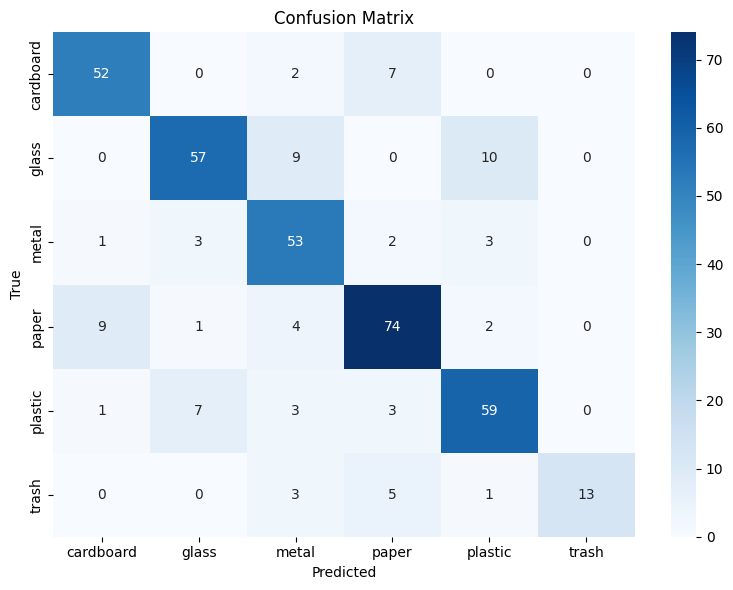

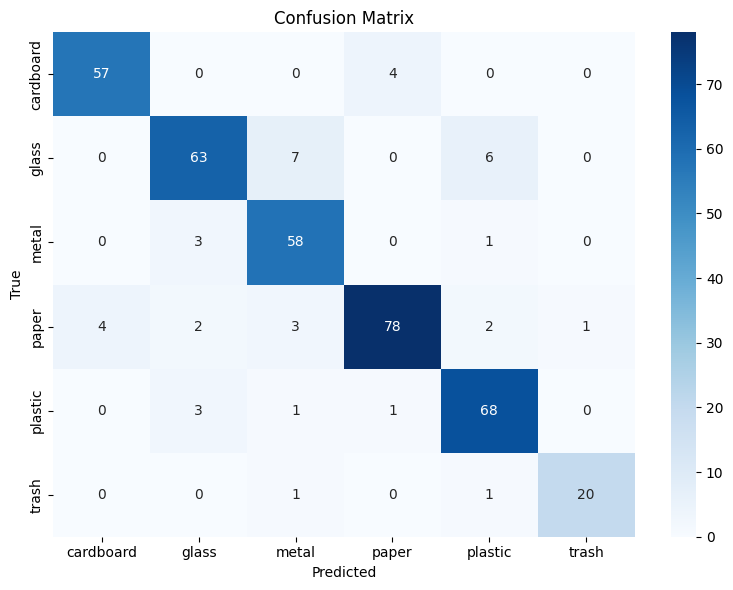

FC-only: {'accuracy': 0.8020833333333334, 'precision': 0.8299503025973612, 'recall': 0.7797747028807279, 'f1_score': 0.7946036844928989, 'confusion_matrix': array([[52,  0,  2,  7,  0,  0],
       [ 0, 57,  9,  0, 10,  0],
       [ 1,  3, 53,  2,  3,  0],
       [ 9,  1,  4, 74,  2,  0],
       [ 1,  7,  3,  3, 59,  0],
       [ 0,  0,  3,  5,  1, 13]])}
Fine-tune: {'accuracy': 0.8958333333333334, 'precision': 0.9023760770103334, 'recall': 0.901020315661606, 'f1_score': 0.9004976465467233, 'confusion_matrix': array([[57,  0,  0,  4,  0,  0],
       [ 0, 63,  7,  0,  6,  0],
       [ 0,  3, 58,  0,  1,  0],
       [ 4,  2,  3, 78,  2,  1],
       [ 0,  3,  1,  1, 68,  0],
       [ 0,  0,  1,  0,  1, 20]])}


In [13]:
# Ví dụ với mô hình FC-only
class_names = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

results_fc = evaluate_model(
    model_fc_only, test_loader, device,
    class_names=class_names,
    model_path='/kaggle/working/checkpoints/fc_only_best.pth'
)

# Với mô hình fine-tune toàn bộ
results_full = evaluate_model(
    model_finetune_all, test_loader, device,
    class_names=class_names,
    model_path='/kaggle/working/checkpoints/full_finetune_best.pth'
)

print("FC-only:", results_fc)
print("Fine-tune:", results_full)

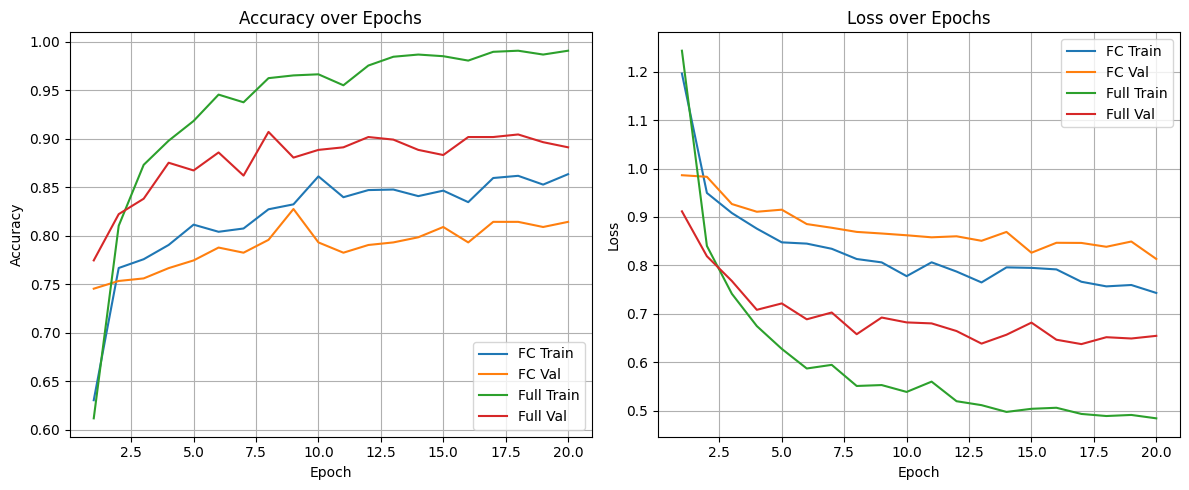

In [14]:
import matplotlib.pyplot as plt

n_epoch = min(len(history_fc['train_loss']), len(history_full['train_loss']))

# Cắt lịch sử để khớp độ dài
for k in ['train_loss', 'val_loss', 'train_acc', 'val_acc']:
    history_fc[k] = history_fc[k][:n_epoch]
    history_full[k] = history_full[k][:n_epoch]

epochs = range(1, n_epoch + 1)
plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, history_fc['train_loss'], label='FC Train')
plt.plot(epochs, history_fc['val_loss'], label='FC Val')
plt.plot(epochs, history_full['train_loss'], label='Full Train')
plt.plot(epochs, history_full['val_loss'], label='Full Val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()
plt.grid(True)

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, history_fc['train_acc'], label='FC Train')
plt.plot(epochs, history_fc['val_acc'], label='FC Val')
plt.plot(epochs, history_full['train_acc'], label='Full Train')
plt.plot(epochs, history_full['val_acc'], label='Full Val')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()